In [2]:
import numpy as np
import phate, magic
import scprep, scanpy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr, pearsonr
import pandas as pd

In [4]:
names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'Eigenscore', 'GFMMD']

clist = ['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal', 'white', 'sienna']

colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000', 'gray':'#808080', 'white':'white', 'sienna':'sienna'}

cmap = {0: 'berry', 1:'light teal', 2:'mustard', 3:'forest', 4:'light purple'}

In [7]:
trajectory_data = np.load('../data/splatter_simulated_data.npz')
data = trajectory_data['data']
true_counts = trajectory_data['true_counts']
true_lib_size = true_counts.T.sum(axis=1)
time = trajectory_data['pseudotime'] / 10000

In [4]:
NCELLS = data.shape[0]
uniform_signal = np.ones((1, NCELLS))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [9]:
cell_phate_op = phate.PHATE(random_state=1234)
cell_data_phate = cell_phate_op.fit_transform(data)

Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 10.00 seconds.
    Calculating KNN search...
    Calculated KNN search in 11.72 seconds.
    Calculating affinities...
    Calculated affinities in 10.81 seconds.
  Calculated graph and diffusion operator in 32.62 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.88 seconds.
    Calculating KMeans...
    Calculated KMeans in 8.35 seconds.
  Calculated landmark operator in 12.04 seconds.
  Calculating optimal t...
    Automatically selected t = 5
  Calculated optimal t in 2.55 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.76 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.13 seconds.
Calculated PHATE in 53.12 seconds.
Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffu

In [ ]:
cell_phate_op = phate.PHATE(random_state=1234)
true_cell_data_phate = cell_phate_op.fit_transform(true_counts)

Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 13.92 seconds.
    Calculating KNN search...
    Calculated KNN search in 16.14 seconds.
    Calculating affinities...
    Calculated affinities in 12.81 seconds.
  Calculated graph and diffusion operator in 42.95 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 2.17 seconds.
    Calculating KMeans...


In [8]:
true_cell_data_phate = true_cell_data_phate * [-1, 1]
cell_data_phate = cell_data_phate * [-1, 1]

<Axes: >

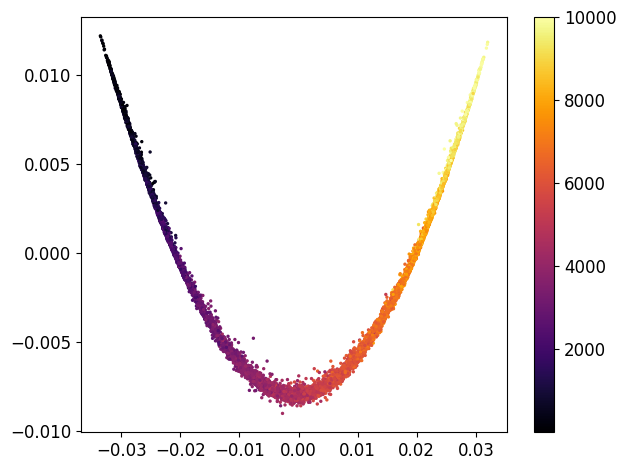

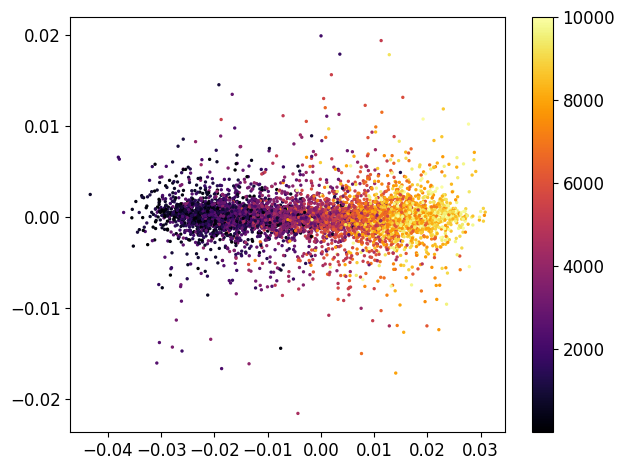

In [9]:
scprep.plot.scatter2d(true_cell_data_phate, trajectory_data['pseudotime'], )
scprep.plot.scatter2d(cell_data_phate, trajectory_data['pseudotime'],)

<Axes: >

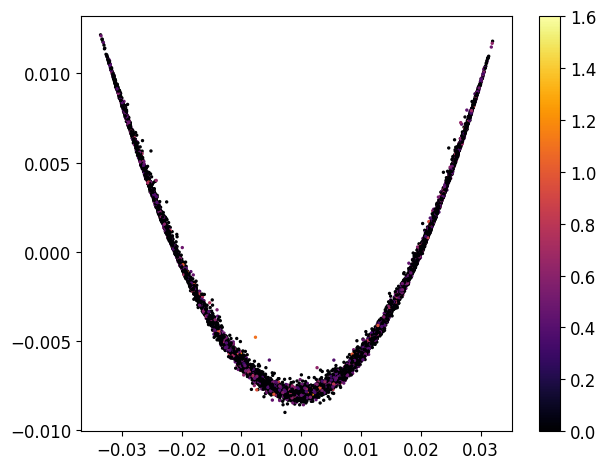

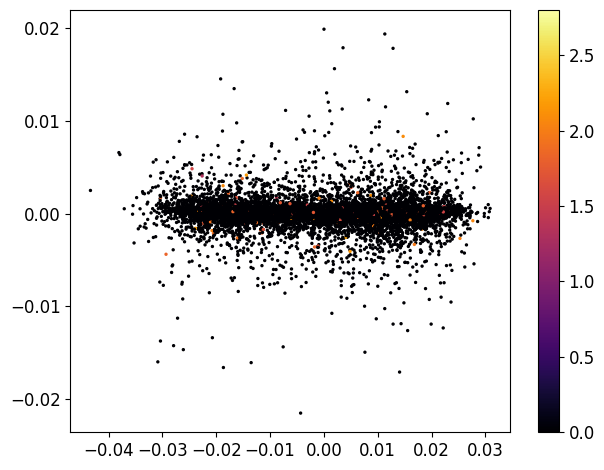

In [15]:
scprep.plot.scatter2d(true_cell_data_phate, true_counts[:, 0], filename='figures/noiseless_gene.png', dpi=200)
scprep.plot.scatter2d(cell_data_phate, data[:, 3421], filename='figures/noisy_gene.png', dpi=200)

In [46]:
embedding = np.load(f'../results/coexpression/GSPA_QR/0_results.npz')['signal_embedding']
localization_score = np.load(f'../results/coexpression/GSPA_QR/0_results.npz')['localization_score']

In [47]:
gene_phate_op = phate.PHATE(random_state=1234)
gene_data_phate = gene_phate_op.fit_transform(embedding)

Calculating PHATE...
  Running PHATE on 8821 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.31 seconds.
    Calculating KNN search...
    Calculated KNN search in 10.10 seconds.
    Calculating affinities...
    Calculated affinities in 8.38 seconds.
  Calculated graph and diffusion operator in 18.85 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.51 seconds.
    Calculating KMeans...
    Calculated KMeans in 6.39 seconds.
  Calculated landmark operator in 9.46 seconds.
  Calculating optimal t...
    Automatically selected t = 6
  Calculated optimal t in 2.50 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.75 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.93 seconds.
Calculated PHATE in 36.50 seconds.


In [48]:
gene_clusters = phate.cluster.kmeans(gene_phate_op, n_clusters=5, random_state=1234)
gene_clusters = scprep.utils.sort_clusters_by_values(gene_clusters, gene_data_phate[:, 0])

/gpfs/gibbs/project/krishnaswamy_smita/av622/conda_envs/gspa/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [49]:
adata = scanpy.AnnData(true_counts)

In [50]:
for c in np.unique(gene_clusters):
    scanpy.tl.score_genes(adata, gene_list=adata.var_names[gene_clusters == c],
                          random_state=0, score_name=f'GM_{c}_score',
                          n_bins=int(adata.n_vars * 0.25))

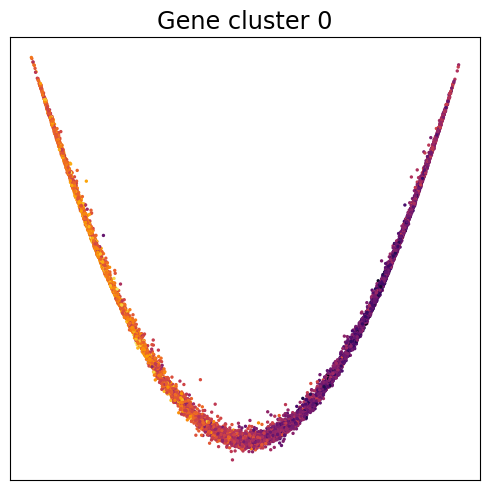

<Figure size 640x480 with 0 Axes>

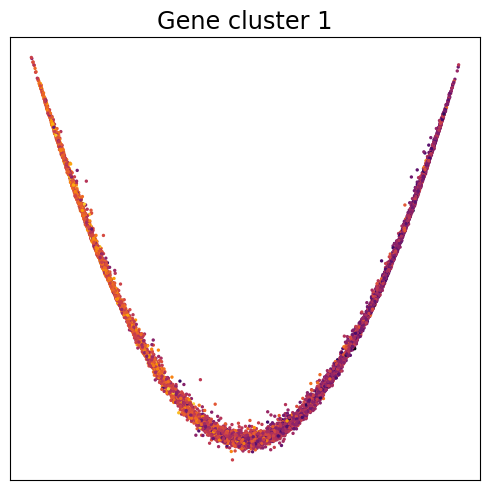

<Figure size 640x480 with 0 Axes>

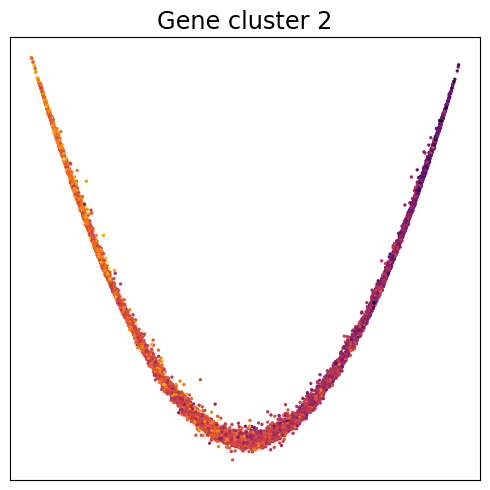

<Figure size 640x480 with 0 Axes>

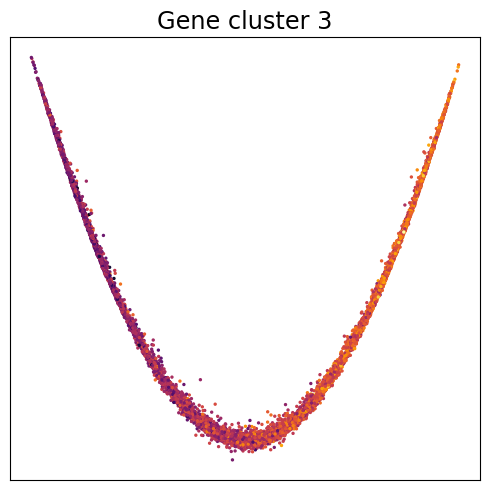

<Figure size 640x480 with 0 Axes>

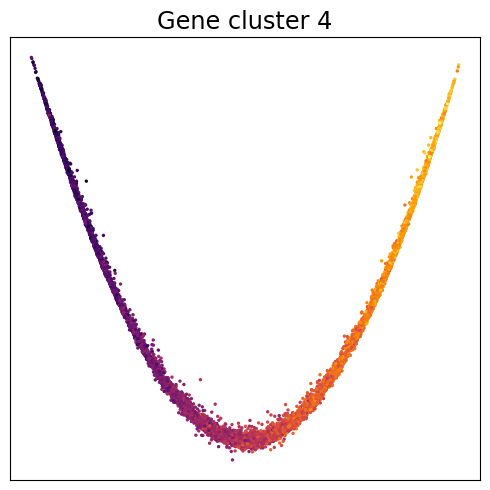

<Figure size 640x480 with 0 Axes>

In [55]:
for c in np.unique(gene_clusters):
    scprep.plot.scatter2d(true_cell_data_phate,
                      c=adata.obs[f'GM_{c}_score'], colorbar=False, ticks=None, figsize=(5,5),
                      title=f'Gene cluster {c}', filename=f'figures/gene_cluster_{c}.png', dpi=200)
    
    plt.show(); plt.clf()

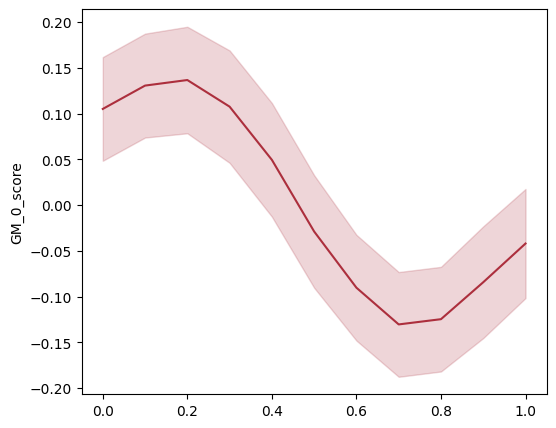

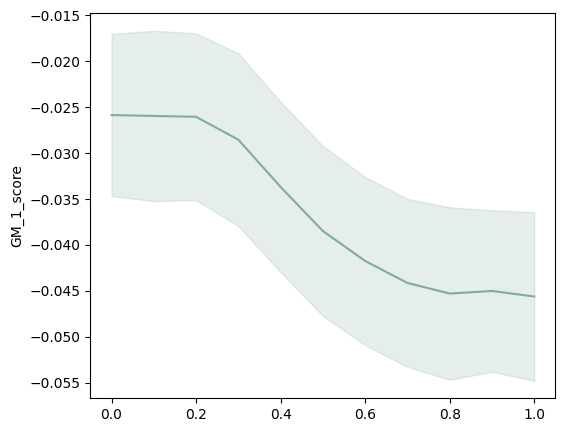

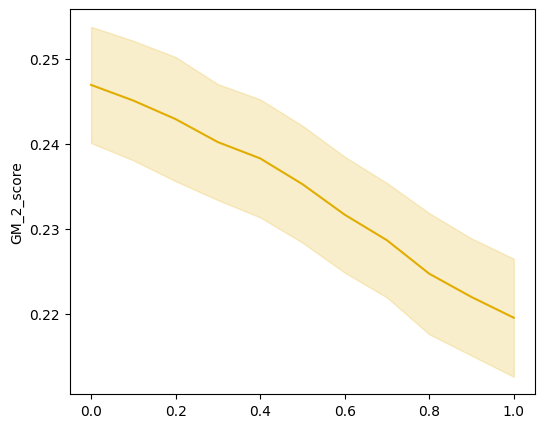

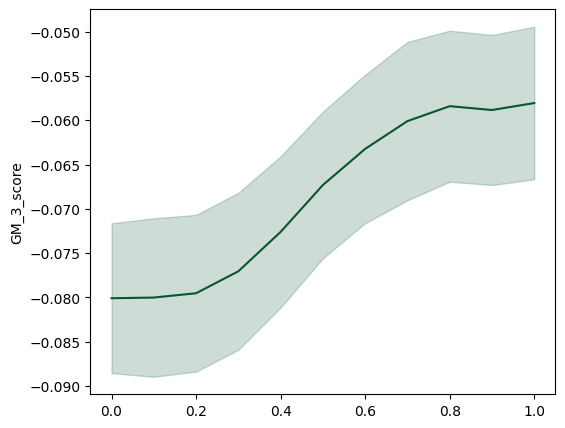

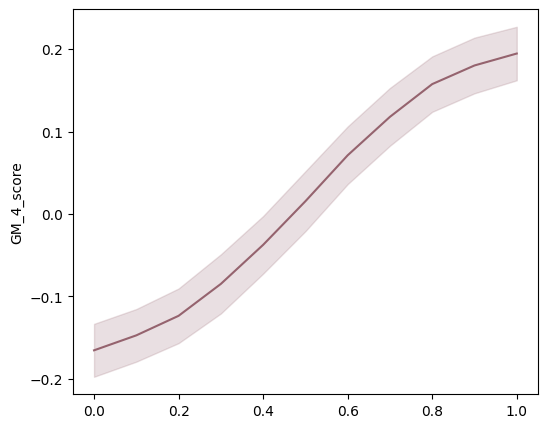

In [54]:
for c in np.unique(gene_clusters):
    fig = plt.figure(figsize=(6,5))
    signal = adata.obs[f'GM_{c}_score']
    sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], errorbar='sd')
    fig.savefig(f'figures/gene_cluster_{c}_over_time.png', dpi=200)

## Embeddings for all approaches

2023-08-28 17:10:08,256:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:10:08,259:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


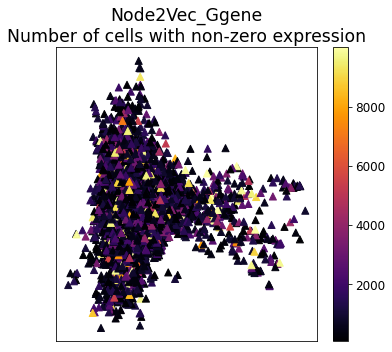

2023-08-28 17:11:38,014:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:11:38,016:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

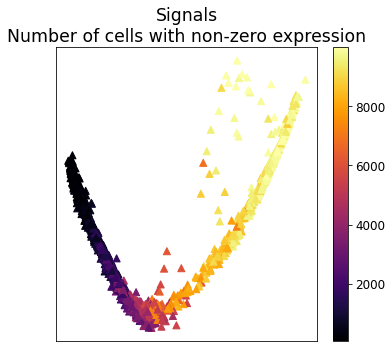

2023-08-28 17:12:55,560:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:12:55,562:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

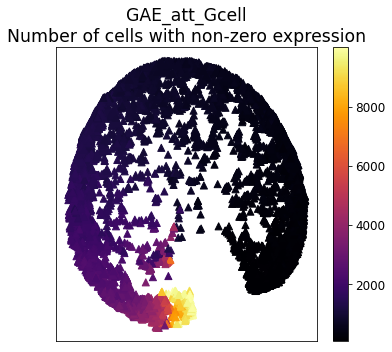

2023-08-28 17:14:17,287:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:14:17,289:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

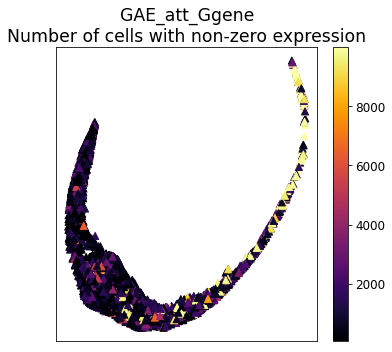

2023-08-28 17:15:39,815:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:15:39,817:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

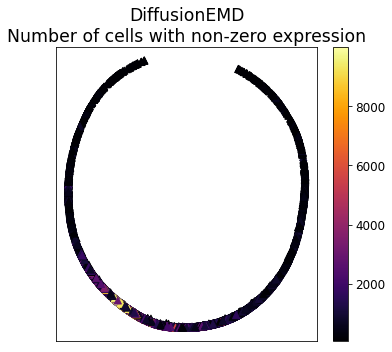

2023-08-28 17:17:00,678:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:17:00,680:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

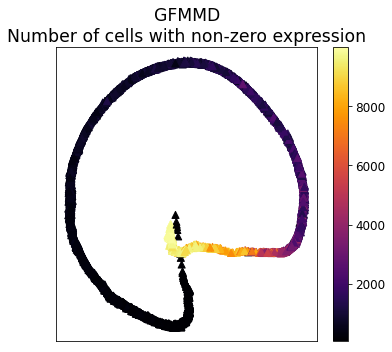

2023-08-28 17:18:19,984:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:18:19,986:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

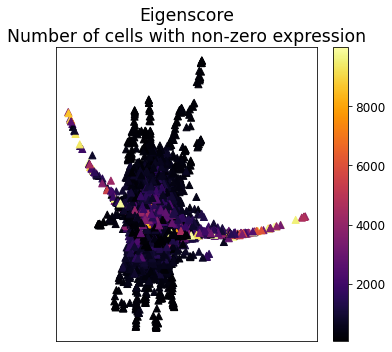

2023-08-28 17:19:51,172:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:19:51,173:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

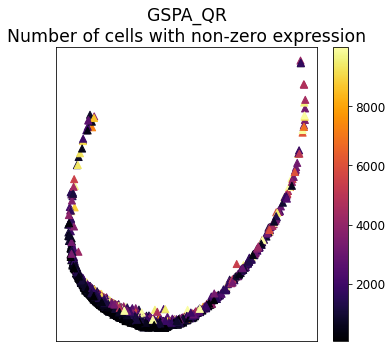

2023-08-28 17:21:04,037:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:21:04,039:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

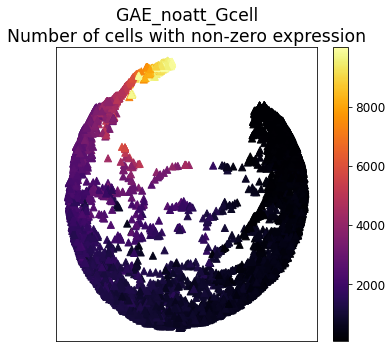

2023-08-28 17:22:33,264:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:22:33,266:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

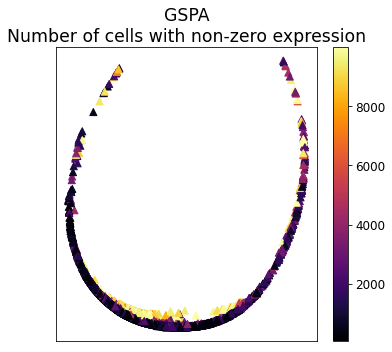

2023-08-28 17:24:02,884:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:24:02,886:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

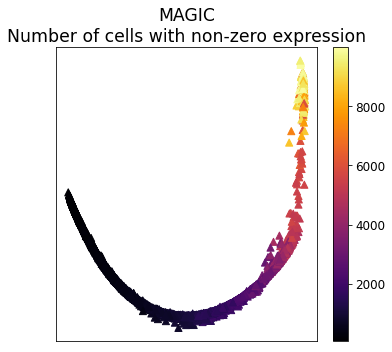

2023-08-28 17:25:11,880:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:25:11,883:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

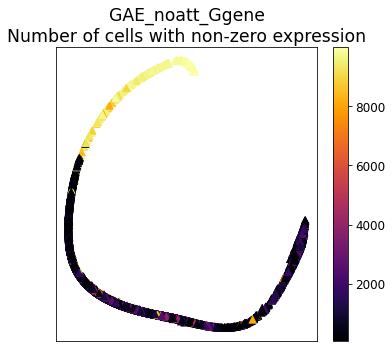

2023-08-28 17:26:40,888:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:26:40,891:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

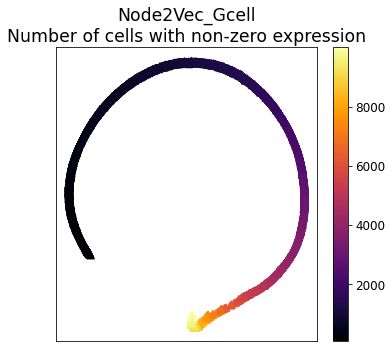

<Figure size 432x288 with 0 Axes>

In [91]:
corr_with_fiedler = {}
for method in os.listdir('../results/coexpression'):
    results = np.load(f'../results/coexpression/{method}/0_results.npz')
    
    gene_phate_op = phate.PHATE(random_state=1234, verbose=False, use_pygsp=True)
    gene_data_phate = gene_phate_op.fit_transform(results['signal_embedding'])
    fiedler = gene_phate_op.graph.U[:, 1]
    corr_with_fiedler[method] = [pearsonr(fiedler, (data > 0).sum(axis=0)).statistic,
                                 pearsonr(fiedler, data.mean(axis=0)).statistic]
    
    scprep.plot.scatter2d(gene_data_phate, marker='^',
                      c=(data > 0).sum(axis=0), s=50, ticks=None, figsize=(5,5),
                          title=method + '\nNumber of cells with non-zero expression',
                      filename=f'figures/{method}_num_cells.png', dpi=200, discrete=False)
    
    
    
    plt.show(); plt.clf()

In [92]:
df = np.abs(pd.DataFrame(corr_with_fiedler)).T.reset_index()

In [93]:
df = df[~df['index'].str.contains('Gcell')].loc[[7,1,11,5,4,9,10,6,3,0]]

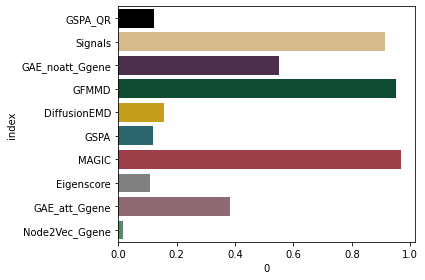

In [105]:
ax = sns.barplot(data=df, y='index', x=0, palette=[colors[x] for x in clist][:10], orient='h')
fig = ax.get_figure()
plt.tight_layout()
fig.savefig('figures/fiedler_corr_with_num_cells_expressed.png', dpi=200)

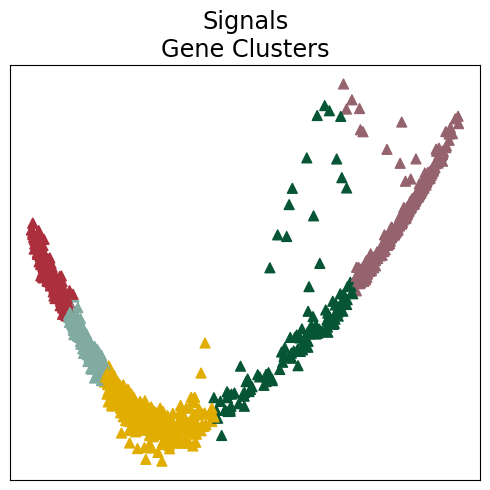

<Figure size 640x480 with 0 Axes>

In [5]:
for method in ['Signals']:
    results = np.load(f'../results/coexpression/{method}/0_results.npz')
    
    gene_phate_op = phate.PHATE(random_state=1234, verbose=False)
    gene_data_phate = gene_phate_op.fit_transform(results['signal_embedding'])
    
    gene_clusters = phate.cluster.kmeans(gene_phate_op, n_clusters=5, random_state=1234)
    gene_clusters = scprep.utils.sort_clusters_by_values(gene_clusters, gene_data_phate[:, 0])
    
    scprep.plot.scatter2d(gene_data_phate, marker='^',
                      s=50, ticks=None, figsize=(5,5), c=[colors[cmap[x]] for x in gene_clusters],
                          title=method + '\nGene Clusters',
                      filename=f'figures/{method}_gene_clusters.png', dpi=200)
    
    plt.show(); plt.clf()

In [8]:
adata = scanpy.AnnData(true_counts)

In [9]:
for c in np.unique(gene_clusters):
    scanpy.tl.score_genes(adata, gene_list=adata.var_names[gene_clusters == c],
                          random_state=0, score_name=f'GM_{c}_score',
                          n_bins=int(adata.n_vars * 0.25))

In [ ]:
for c in np.unique(gene_clusters):
    scprep.plot.scatter2d(true_cell_data_phate,
                      c=adata.obs[f'GM_{c}_score'], colorbar=False,
                      title=method + f'\nGene Cluster {c}', figsize=(5,5), ticks=None,
                      filename=f'figures/{method}_gene_cluster_{c}.png')
    
    plt.show(); plt.clf()

In [ ]:
for c in np.unique(gene_clusters):
    fig = plt.figure(figsize=(6,5))
    signal = adata.obs[f'GM_{c}_score']
    sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], errorbar='sd')
    fig.savefig(f'figures/{method}_gene_cluster_{c}_over_time.png', dpi=200)